In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
import seaborn as sns
import os

In [3]:
file_path = "C:/Users/marle/Desktop/ML/Mall_Customers.csv"

if os.path.exists(file_path):
    df=pd.read_csv(file_path)
    print('wczytano dane z pliku:', file_path)
else:
    print("nie udało sie wczytać pliku, generujemy")
print("pierwsze 5 wierszy:")
print(df.head())
print("podstawowe statystyki:")
print(df.describe())

wczytano dane z pliku: C:/Users/marle/Desktop/ML/Mall_Customers.csv
pierwsze 5 wierszy:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
podstawowe statystyki:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000  

In [4]:
print("\n",df.dtypes)
if 'CustomerID' in df.columns:
    df = df.drop('CustomerID', axis=1) #usunieto kolumne id
#kodowanie płci
if 'Genre' in df.columns:
    #labelencoder przypisuje male 0, a female 1
    le=LabelEncoder()
    df['Genre'] = le.fit_transform(df['Genre'])
else:
    print("koolumna genre ni istnieje")
print("typy danych po przetworzeniu:")
print(df.dtypes)


 CustomerID                 int64
Genre                     object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object
typy danych po przetworzeniu:
Genre                     int32
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object


In [6]:
#wybór cech do grupowania - bierzemy wszystkie
features = df.columns.tolist()
X=df[features].values

print("kształt macierxy cech:", X.shape)
print("pierwsze 5 wierszy danych numeryczne: ",X[:5])
#skalowanie danych:
scaler= StandardScaler()
X_scaled = scaler.fit_transform(X)

kształt macierxy cech: (200, 4)
pierwsze 5 wierszy danych numeryczne:  [[ 1 19 15 39]
 [ 1 21 15 81]
 [ 0 20 16  6]
 [ 0 23 16 77]
 [ 0 31 17 40]]


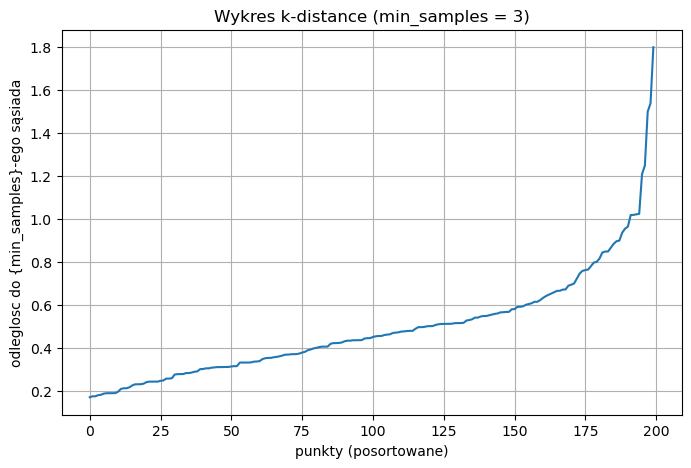

In [7]:
#dobr parametru eps
min_samples = 3
neigh = NearestNeighbors(n_neighbors=min_samples)
nbrs = neigh.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled) #dla kazdego punktu dostajemy indeksy i odległośc najblizszych sasiadów
k_dist = np.sort(distances[:, min_samples-1],axis=0)

plt.figure(figsize=(8,5))
plt.plot(k_dist)
plt.title('Wykres k-distance (min_samples = {})'.format(min_samples))
plt.xlabel('punkty (posortowane)')
plt.ylabel('odleglosc do {min_samples}-ego sąsiada')
plt.grid(True)
#plt.show()

eps= 0.5 # na podstawie wykresu


In [9]:
db = DBSCAN(eps=eps, min_samples=min_samples)
labels = db.fit_predict(X_scaled) #uczy sie strukltury i przypisuje do klastra, decyduje czy punkt nalezy do klastra czy nie
print(labels)
#labels - tablica z numerami klastrów dla każdego punktu w zbioerze, jeśli jest -1 to oznacza że punkt jst szumm
unique_labels=set(labels)
n_clusters= len(unique_labels)-(1 if -1 in unique_labels else 0)
n_noise = list(labels).count(-1)
print("liczba znalezionych klastrów: ", n_clusters)
print("etykiety klastroW: ", unique_labels)
print("liczba szumu: ",n_noise)
#dodanie etykiet do danych i zapis
df['cluster'] = labels
output_file = "mail_customers_with_clusters.csv"
df.to_csv(output_file, index = False)
print("zapisano wyniki do pliku: {}".format(output_file))

[-1  1 -1  0  2  0 -1 -1 -1  0 -1 -1  3  0 -1  1  2  1 -1 -1 -1  1 -1  1
  3  1  2 -1  2  0 -1  0 -1 -1  3  0 -1 -1  2  0 -1 -1  6  5 -1  0  4  5
  5  5  4 -1  5  6  4  6  4  6  5  6  6  7  8  4  6  7  4  8  7  5  6  4
  4  4  6  9  4 -1  5  4  6 -1  6  4  5  6  4  5 -1  4  8  9  6  5  5  9
  4  5  6  9  5  4  6  9  6  5  8  6  6  6  6  5  5  9  5  5  8  4  4  4
  9  5 -1 10  5 11 -1 10 -1 12 -1 12  5 11 13 11 15 12 13 11 -1 10  5 11
 13 10 -1 11 16 10 14 10 15 11 15 11 14 11 14 11 -1 11 13 11 -1 11 14 11
 16 17 14 17 14 10 -1 11 -1 17 -1 10 16 11 -1 11 16 -1 -1 -1 -1 11 16 -1
 -1 11 -1 -1 -1 -1 -1 -1]
liczba znalezionych klastrów:  18
etykiety klastroW:  {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, -1}
liczba szumu:  49
zapisano wyniki do pliku: mail_customers_with_clusters.csv


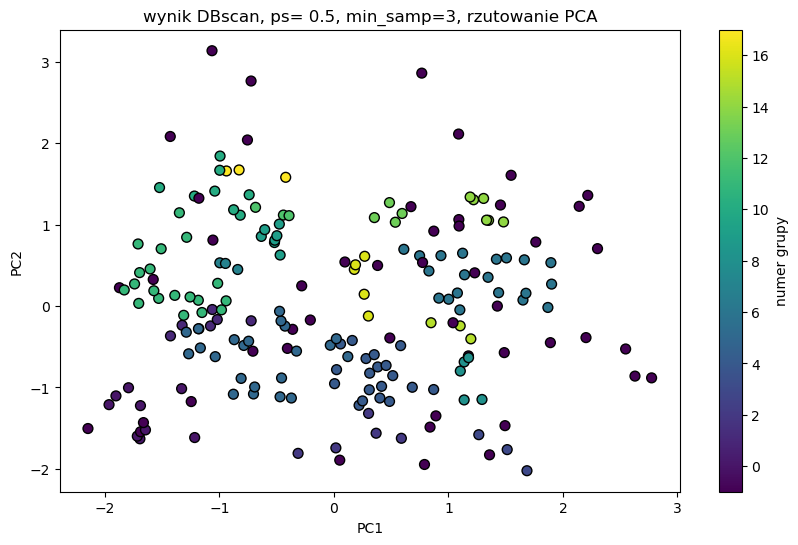

In [10]:

#wizualizacja - redukcja wymiaru do 2D za pomocą pca
pca=  PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(10,6))
scatter= plt.scatter(X_pca[:,0],X_pca[:,1], c=labels, cmap='viridis', edgecolors='k', s=50)
plt.colorbar(scatter, label='numer grupy')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('wynik DBscan, ps= {}, min_samp={}, rzutowanie PCA'.format(eps, min_samples))
plt.show()